In [1]:
from brian2 import *
import numpy as np
from os import listdir
from pathlib import Path
import matplotlib.pyplot as plt
import random as rng
from scipy import constants as constants
import re
defaultclock.dt = 1 * ms
prefs.codegen.target = 'numpy'

In [2]:
#get the number of trial
def get_nb_trial():
    folder = Path("./Preprocessed_data")
    num_files = sum(1 for p in folder.iterdir() if p.is_file())

    return num_files

#import preprocessed fingertip data from folder
def read_data_preprocessed(trial):
    paths = sorted(Path("./Preprocessed_data").glob(f"*_{trial}.csv"))
    filename = paths[0]
    stem = filename.stem
    stim_part = stem.rsplit("_", 1)[0]
    if not paths:
        raise FileNotFoundError(f"No CSV found for trial {trial}")
    
    
    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", stim_part)
    if not m:
        raise ValueError(f"Could not parse numeric stimulus from '{stim_part}'")
    stimulus = m.group(0)

    return np.loadtxt(str(paths[0]), delimiter=","), stimulus  # or genfromtxt if messy CSVs

In [3]:
def generate_position_x_y(popsize, max_x, min_x, max_y, min_y):

    xs = []
    ys = []
    for i in range(popsize):

        x0 = np.random.default_rng().integers(min_x, max_x)
        y0 = np.random.default_rng().integers(min_y, max_y)        # position_x_fav, position_y_fav
        # Parameters (you can tweak these)
        xs.append(x0)
        ys.append(y0)
    return xs, ys

def create_stim_static_position(duration, x_val, y_val, dt):

    stim_position_x = []
    stim_position_y = []
    for i in range(duration):
        stim_position_x.append(x_val)
        stim_position_y.append(y_val)

    return TimedArray(stim_position_x, dt=dt), TimedArray(stim_position_y, dt=dt)

def create_stim_amp_from_data(data, dt):
    return TimedArray(data, dt)

def create_amplitude_on_off(amplitude, thresh, dt):
    amp_on_off = np.zeros(len(amplitude))
    amp_on_off[amplitude >= thresh] = 1
    return TimedArray(amp_on_off, dt=dt)

In [4]:
#Mechanoreceptor fingertip (2D gaussian)
#TODO Replace the sread_x and spread_y with validated receptive field size for each receptor
# SA1 6-8mm spread_x, spread_y
SA1 = '''
resp_curve = (exp(-(((position_x(t) - position_x_fav)**2) / (2*8**2)) - (((position_y(t) - position_y_fav)**2) / (2*8**2)))) : 1
Iapp = I(t) * (amplitudeOnOff(t)) * 2 * (resp_curve) : amp
dISRA_SA1/dt = (a_SA1 * (v  - El_tg) - ISRA_SA1)/tau_SRA1 : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_SA1 + Iapp + randn() * noiseSA1 * pA)/Cm : volt

position_x_fav : 1
position_y_fav : 1
noiseSA1 : 1
'''

# RA 8 mm spread spread_x, spread_y
RA = '''

ampdif = (amplitude(t) - amplitude(t-(1 * dt))) ** 2 : 1
resp_curve = (exp(-(((position_x(t) - position_x_fav)**2) / (2*4**2)) - (((position_y(t) - position_y_fav)**2) / (2*4**2)))) : 1
Iapp = I(t) * (amplitudeOnOff(t)) * log(1 + ampdif) * (1 + resp_curve) : amp
dISRA_RA/dt = (a_RA * (v  - El_tg) - ISRA_RA)/tau_RA : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_RA + Iapp + randn() * noiseRA * pA)/Cm : volt

position_x_fav : 1
position_y_fav : 1
noiseRA : 1
'''

# SA2 16mm spread spread_x, spread_y
SA2 = '''
resp_curve = (exp(-(((position_x(t) - position_x_fav)**2) / (2*16**2)) - (((position_y(t) - position_y_fav)**2) / (2*16**2)))) : 1
Iapp = I(t) * amplitudeOnOff(t) * (amplitude(t)/90) * (resp_curve) : amp
dISRA_SA2/dt = (a_SA2 * (v  - El_tg) - ISRA_SA2)/tau_SRA2 : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_SA2 + Iapp + randn() * noiseSA2 * pA)/Cm : volt

position_x_fav : 1
position_y_fav : 1
noiseSA2 : 1
'''

tg = '''
dISRA/dt = (a_null * (v  - El_tg) - ISRA)/tau_SRA_null : amp
Il = Gl_bar * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA + Iapp)/Cm : volt

Iapp : amp
'''

In [5]:
def compute_spontaneous_activity(spike_times, duration):
    spontaneous_activity = np.zeros((duration, 1))
    spike_times = np.round(spike_times/ms)
    for i in range(duration):
        spontaneous_activity[i] = sum(spike_times==i)
    return spontaneous_activity

In [6]:
def compute_nb_spike_per_neuron(spike, nb_neuron):
    nb_spike=np.zeros(nb_neuron)
    for i in np.unique(spike.i):
        nb_spike[i] = sum(spike.i == i)
    return nb_spike


In [7]:
TH_eq = '''
dv/dt = (Iapp - INa - IK - IT - Ih - ILeak - IKleak)/Cm : volt

INa = gNa * m**3 * h * (v - ENa) : amp/meter**2
IK = gK * n**4 * (v - EK) : amp/meter**2
ILeak = gleak * (v - Eleak) : amp/meter**2
IKleak = gKleak * (v - EKleak) : amp/meter**2
IT = gCa * mT_inf**2 * hT * (v - ECa) : amp/meter**2
Ih = gh * (o1 + 2*(1 - c1 - o1)) * (v - Eh) : amp/meter**2

dm/dt = alpha_m * (1 - m) - beta_m * m : 1
dh/dt = alpha_h * (1 - h) - beta_h * h : 1
dn/dt = alpha_n * (1 - n) - beta_n * n : 1
dhT/dt = (hT_inf - hT) / tau_hT : 1

ECa = ((GasConst * 309.15*kelvin) / (2 * FaradConst)) * log(2 / CaBuffer) : volt
CaBufferTemp = ((-10 * IT/(amp/meter**2)) / (2 * FaradConst / (coulomb/mole))) : 1
dCaBuffer/dt = (int(CaBufferTemp > 0) * CaBufferTemp + (0.00024-CaBuffer)/5 ) / ms : 1 

do1/dt = (0.001 * (1 - c1 - o1) - 0.001 * ( (1-p0) / 0.01)) * o1 / ms : 1
dp0/dt = (0.0004 *  (1 - p0) - 0.0004 * ((CaBuffer / 0.002)**4) * p0) / ms : 1
dc1/dt = beta * o1 - alpha * c1 : 1

alpha_m = ((0.32 * (13 - (v/mV + 35))) / (exp((13 - (v/mV + 35))/4) - 1)) / ms : Hz
beta_m = ((0.28 * ((v/mV + 35) - 40)) / (exp(((v/mV + 35) - 40)/5) - 1)) / ms : Hz
alpha_h = (0.128 * exp((17 - v/mV - 35)/18)) / ms : Hz
beta_h = (4 / (1 + exp((40 - v/mV - 35)/5))) / ms : Hz

alpha_n = ((0.032 * (15 - (v/mV + 25))) / (exp((15 - (v/mV + 25))/5) - 1)) / ms : Hz
beta_n = (0.5 * exp((10 - (v/mV + 25)) / 40)) / ms : Hz

alpha = h_inf / tau_s : Hz
beta = (1 - h_inf) / tau_s : Hz

mT_inf = 1 / (1 + exp((-((v/mV + 2) + 57)) / 6.2)) : 1
hT_inf = 1 / (1 + exp(((v/mV + 2) + 81)/4)) : 1
tau_hT = (( 30.8 + (211.4 + exp(((v/mV+2) + 113.2)/5))/(1+exp(((v/mV + 2)+84)/3.2))) / 3.73) * ms : second

h_inf =  1 / (1 + exp( (v/mV + 75)/5.5 )) : 1
tau_s = (20 + 1000 / (exp( (v/mV + 71.5)/14.2 ) + exp( (-(v/mV + 89))/11.6))) * ms: second
    
Cm = 1*uF/cm**2 : farad/meter**2
Iapp : amp/meter**2

taud : second
taur : second
slope : volt

ds1/dt = -s1/taud + 1/2 * (1 + (tanh(v/slope)))* (1-s1)/taur : 1 
'''

CTX_eq = '''

gaba2 : 1
ampa2 : 1
taud_g : second
taur_g : second
slope_g : volt
gsyn_g : siemens/meter**2
Esyn_g : volt
taud_a : second
taur_a : second
slope_a : volt
gsyn_a : siemens/meter**2
Esyn_a : volt

Cm = 1*uF/cm**2 : farad/meter**2
gleak : siemens/meter**2
gNa : siemens/meter**2
gK : siemens/meter**2
gM  : siemens/meter**2
Eleak : volt
V_T : volt
tau_max_M : second

random_var : 1
noise_std = 5 * mA/meter**2 : amp/meter**2
noise_mean = 0 * nA/meter**2 : amp/meter**2
Inoise = noise_mean + noise_std * random_var: amp/meter**2

beta_n = 0.50 * exp( -(v-V_T - 10.0*mV)/(40.0*mV))*1/msecond : Hz
alpha_n = -0.0320/mV*(v-V_T-15.0*mV) / (exp( -(v-V_T - 15.0*mV)/(5.0*mV)) - 1) * 1/msecond : Hz
dn/dt = alpha_n * (1-n) - beta_n * n: 1

alpha_m =  -0.32/mV*(v-V_T-13.*mV) / (exp(-(v-V_T-13.*mV)/(4.*mV))-1) * 1/msecond : Hz
beta_m = ( 0.28/mV * ((v-V_T-40.*mV))) / (exp((v-V_T-40.*mV)/(5.*mV))-1 ) * 1/msecond : Hz
dm/dt = alpha_m * (1-m) - beta_m * m : 1

alpha_h = 0.128 * exp(-(v-V_T-17.*mV)/(18.*mV)) * 1/msecond : Hz
beta_h = 4./(1.+exp(-(v-V_T-40.*mV)/(5.*mV))) * 1/msecond : Hz
dh/dt = alpha_h * (1-h) - beta_h * h: 1


p_inf = 1 / (1.+exp(-(v+35.*mV)/(10.*mV))) : 1
tau_p = tau_max_M /( (3.3*exp((v+35.*mV)/(20.*mV)) + exp(-(v+35.*mV)/(20.*mV)))) : second
dp/dt = (p_inf - p)/tau_p : 1

IK    = -gK * n**4 *(v-EK_ctx) : ampere/meter**2
INa   = -gNa*m**3*h*(v-ENa_ctx)   : ampere/meter**2
IM    = -gM *p *(v-EM_ctx)  : ampere/meter**2
Ileak = -gleak*(v-Eleak): ampere/meter**2

dgaba1/dt = -gaba1/taud_g + 1/2 * (1 + (tanh(v/slope_g)))* (1-gaba1)/taur_g : 1 
dampa1/dt = -ampa1/taud_a + 1/2 * (1 + (tanh(v/slope_a)))* (1-ampa1)/taur_a : 1 

Igaba = -gsyn_g * gaba2 * (v-Esyn_g): amp/meter**2
Iampa = -gsyn_a * ampa2 * (v-Esyn_a): amp/meter**2



dv/dt = (IK + INa + IM + Ileak + Igaba + Iampa + Inoise)/Cm  : volt
'''

VPM = '''
dv/dt = (Iapp - INa - IK - IT - Ih - ILeak - IKleak)/Cm : volt

INa = gNa_vpm * m**3 * h * (v - ENa_vpm) : amp/meter**2
IK = gK_vpm * n**4 * (v - EK_vpm) : amp/meter**2
ILeak = gleak_vpm * (v - Eleak_vpm) : amp/meter**2
IKleak = gKleak_vpm * (v - EKleak_vpm) : amp/meter**2
IT = gCa_vpm * mT_inf**2 * hT * (v - ECa) : amp/meter**2
Ih = gh_vpm * (o1 + 2*(1 - c1 - o1)) * (v - Eh_vpm) : amp/meter**2

dm/dt = alpha_m * (1 - m) - beta_m * m : 1
dh/dt = alpha_h * (1 - h) - beta_h * h : 1
dn/dt = alpha_n * (1 - n) - beta_n * n : 1
dhT/dt = (hT_inf - hT) / tau_hT : 1

ECa = ((GasConst * 309.15*kelvin) / (2 * FaradConst)) * log(2 / CaBuffer) : volt
CaBufferTemp = ((-10 * IT/(amp/meter**2)) / (2 * FaradConst / (coulomb/mole))) : 1
dCaBuffer/dt = (int(CaBufferTemp > 0) * CaBufferTemp + (0.00024-CaBuffer)/5 ) / ms : 1 

do1/dt = (0.001 * (1 - c1 - o1) - 0.001 * ( (1-p0) / 0.01)) * o1 / ms : 1
dp0/dt = (0.0004 *  (1 - p0) - 0.0004 * ((CaBuffer / 0.002)**4) * p0) / ms : 1
dc1/dt = beta * o1 - alpha * c1 : 1

alpha_m = ((0.32 * (13 - (v/mV + 35))) / (exp((13 - (v/mV + 35))/4) - 1)) / ms : Hz
beta_m = ((0.28 * ((v/mV + 35) - 40)) / (exp(((v/mV + 35) - 40)/5) - 1)) / ms : Hz
alpha_h = (0.128 * exp((17 - v/mV - 35)/18)) / ms : Hz
beta_h = (4 / (1 + exp((40 - v/mV - 35)/5))) / ms : Hz

alpha_n = ((0.032 * (15 - (v/mV + 25))) / (exp((15 - (v/mV + 25))/5) - 1)) / ms : Hz
beta_n = (0.5 * exp((10 - (v/mV + 25)) / 40)) / ms : Hz

alpha = h_inf / tau_s : Hz
beta = (1 - h_inf) / tau_s : Hz

mT_inf = 1 / (1 + exp((-((v/mV + 2) + 57)) / 6.2)) : 1
hT_inf = 1 / (1 + exp(((v/mV + 2) + 81)/4)) : 1
tau_hT = (( 30.8 + (211.4 + exp(((v/mV+2) + 113.2)/5))/(1+exp(((v/mV + 2)+84)/3.2))) / 3.73) * ms : second

h_inf =  1 / (1 + exp( (v/mV + 75)/5.5 )) : 1
tau_s = (20 + 1000 / (exp( (v/mV + 71.5)/14.2 ) + exp( (-(v/mV + 89))/11.6))) * ms: second

Cm = 1*uF/cm**2 : farad/meter**2
Iapp : amp/meter**2

taud : second
taur : second
slope : volt

ds1/dt = (-s1/taud + 1/2 * (1 + (tanh(v/slope)))* (1-s1)/taur) : 1 
'''

#Replace 200 by noiseSA1 or noiseSA2
#Replace 200 by noiseSA1 or noiseSA2

In [18]:
def model_mechano_TH_CTX(SA1_position_x_fav, SA1_position_y_fav, SA2_position_x_fav, SA2_position_y_fav, RA_position_x_fav, RA_position_y_fav,
                         S4_src, S5_src, S6_src, VPM_to_L4E_src, VPM_to_L4I_src, L4E_to_L4E_src, L4E_to_L4I_src, L4I_to_L4E_src, L4I_to_L4I_src, L4E_to_L3E_src, L4E_to_L3I_src, L4I_to_L3E_src, L3E_to_L3E_src, L3E_to_L3I_src, L3I_to_L3E_src, L3I_to_L3I_src, L3E_to_L2E_src, L3E_to_L2I_src, L3I_to_L2E_src, L3I_to_L2I_src, L2E_to_L2E_src, L2E_to_L2I_src, L2I_to_L2E_src, L2I_to_L2I_src,
                         S4_targ, S5_targ, S6_targ, VPM_to_L4E_targ, VPM_to_L4I_targ, L4E_to_L4E_targ, L4E_to_L4I_targ, L4I_to_L4E_targ, L4I_to_L4I_targ, L4E_to_L3E_targ, L4E_to_L3I_targ, L4I_to_L3E_targ, L3E_to_L3E_targ, L3E_to_L3I_targ, L3I_to_L3E_targ, L3I_to_L3I_targ, L3E_to_L2E_targ, L3E_to_L2I_targ, L3I_to_L2E_targ, L3I_to_L2I_targ, L2E_to_L2E_targ, L2E_to_L2I_targ, L2I_to_L2E_targ, L2I_to_L2I_targ):
    Eleak = -70*mV 
    spike_detect = 0*mV
    VPM_neuron_num = 70
    L4E_neuron_num = 188
    L4I_neuron_num = 33
    L3E_neuron_num = 158
    L3I_neuron_num = 28
    L2E_neuron_num = 86
    L2I_neuron_num = 15

    ENa_vpm = 50*mV 
    EK_vpm = -100*mV 

    Eh_vpm = -43*mV 
    Eleak_vpm = -70*mV 
    EKleak_vpm = -100*mV

    gNa_vpm = 90*msiemens/cm**2
    gK_vpm = 20*msiemens/cm**2
    gCa_vpm = 2*msiemens/cm**2
    gh_vpm = 0.01*msiemens/cm**2
    gleak_vpm = 0.01*msiemens/cm**2
    gKleak_vpm = 0.0172*msiemens/cm**2

    FaradConst = constants.physical_constants['Faraday constant'][0] * coulomb/mole
    GasConst = constants.gas_constant * joule / (kelvin * mole)

    ########### Constants for CTX/L4 cells ###########

    # Regular-spiking param-values
    RS_gleak     = 1.05e-5      * siemens/cm**2
    RS_Eleak     = -70.3        * mV
    RS_V_T       = -59          * mV
    RS_gNa       = 0.086        * siemens/cm**2
    RS_gK        = 0.006        * siemens/cm**2
    RS_gM        = 15e-5        * siemens/cm**2 
    RS_tau_max_M = 808          * ms

    # Fast-spiking param-values
    FS_diam      = 56.9        * um
    FS_surface   = pi*FS_diam**2

    FS_gleak     = 3.8e-5       * siemens/cm**2
    FS_Eleak     = -70.4        * mV
    FS_gNa       = 0.078        * siemens/cm**2
    FS_V_T       = -58          * mV
    FS_gK        = 0.0039       * siemens/cm**2
    FS_gM        = 5e-5         * siemens/cm**2
    FS_tau_max_M = 602          * ms
        
    # Shared values
  

    El= -50 * mV

    SA1_pop = NeuronGroup(24, SA1, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA1 = ISRA_SA1 + b_SA1''', dt = 1*ms)
    SA2_pop = NeuronGroup(10, SA2, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA2 = ISRA_SA2 + b_SA2''', dt = 1*ms)
    RA_pop = NeuronGroup(36, RA, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_RA = ISRA_RA''', dt = 1*ms)
    TG_pop = NeuronGroup(70, tg, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg''', dt = 1*ms)
    BS_pop = NeuronGroup(70, tg, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg''', dt = 1*ms)
    
    TC_pop = NeuronGroup(VPM_neuron_num, VPM, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method='rk4', dt=0.01*ms)
    TC_pop.v = -65*mV + (10 * np.random.rand(1, VPM_neuron_num) * mV)  # Resting potential

    #TC_pop.m = 0 + np.finfo(float).eps
    #TC_pop.h = 0 + np.finfo(float).eps
    #TC_pop.n = 0 + np.finfo(float).eps
    #TC_pop.hT = 0 + np.finfo(float).eps
    TC_pop.CaBuffer = 0 + np.finfo(float).eps
    #TC_pop.o1 = 0 + np.finfo(float).eps
    #TC_pop.c1 = 0 + np.finfo(float).eps
    #TC_pop.p0 = 0 + np.finfo(float).eps

    L4E_cells = NeuronGroup(L4E_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L4E_cells.gleak    =   RS_gleak
    L4E_cells.Eleak    =   RS_Eleak
    L4E_cells.V_T      =   RS_V_T
    L4E_cells.gNa      =   RS_gNa
    L4E_cells.gK       =   RS_gK
    L4E_cells.gM       =   RS_gM
    L4E_cells.tau_max_M =  RS_tau_max_M
    L4E_cells.v        =   -65 * mV

    L4I_cells = NeuronGroup(L4I_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L4I_cells.gleak    =   FS_gleak
    L4I_cells.Eleak    =   FS_Eleak
    L4I_cells.V_T      =   FS_V_T
    L4I_cells.gNa      =   FS_gNa
    L4I_cells.gK       =   FS_gK
    L4I_cells.gM       =   FS_gM
    L4I_cells.tau_max_M =  FS_tau_max_M
    L4I_cells.v        =   -65 * mV

    L3E_cells = NeuronGroup(L3E_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L3E_cells.gleak    =   RS_gleak
    L3E_cells.Eleak    =   RS_Eleak
    L3E_cells.V_T      =   RS_V_T
    L3E_cells.gNa      =   RS_gNa
    L3E_cells.gK       =   RS_gK
    L3E_cells.gM       =   RS_gM
    L3E_cells.tau_max_M =  RS_tau_max_M
    L3E_cells.v        =   -65 * mV

    L3I_cells = NeuronGroup(L3I_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L3I_cells.gleak    =   FS_gleak
    L3I_cells.Eleak    =   FS_Eleak
    L3I_cells.V_T      =   FS_V_T
    L3I_cells.gNa      =   FS_gNa
    L3I_cells.gK       =   FS_gK
    L3I_cells.gM       =   FS_gM
    L3I_cells.tau_max_M =  FS_tau_max_M
    L3I_cells.v        =   -65 * mV

    L2E_cells = NeuronGroup(L2E_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L2E_cells.gleak    =   RS_gleak
    L2E_cells.Eleak    =   RS_Eleak
    L2E_cells.V_T      =   RS_V_T
    L2E_cells.gNa      =   RS_gNa
    L2E_cells.gK       =   RS_gK
    L2E_cells.gM       =   RS_gM
    L2E_cells.tau_max_M =  RS_tau_max_M
    L2E_cells.v        =   -65 * mV

    L2I_cells = NeuronGroup(L2I_neuron_num, CTX_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method = 'rk4', dt=0.01*ms)

    L2I_cells.gleak    =   FS_gleak
    L2I_cells.Eleak    =   FS_Eleak
    L2I_cells.V_T      =   FS_V_T
    L2I_cells.gNa      =   FS_gNa
    L2I_cells.gK       =   FS_gK
    L2I_cells.gM       =   FS_gM
    L2I_cells.tau_max_M =  FS_tau_max_M
    L2I_cells.v        =   -65 * mV

    # AMPA params
    Esyn_AMPA = 0       * mV  
    gsyn_AMPA = 0.1 * 0.17 * 10   * msiemens/cm**2
    slope_AMPA = 10     * mvolt
    taud_AMPA = 2       * ms
    taur_AMPA = 0.1     * ms

    # GABA params
    Esyn_GABA = -80         * mV 
    gsyn_GABA = 0.25 * 0.5   * msiemens/cm**2 
    taud_GABA = 10      * ms
    taur_GABA = 0.2     * ms
    slope_GABA = 10     * mvolt

    S1 = Synapses(SA1_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 1 * ms)
    S1.connect(condition='i==j')
    S2 = Synapses(SA2_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 1 * ms)
    S2.connect(condition='i+24==j')
    S3 = Synapses(RA_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 1 * ms)
    S3.connect(condition='i+36==j')
    S4 = Synapses(TG_pop, BS_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 1 * ms)
    S4.connect(condition='i==j')
    S5 = Synapses(BS_pop, BS_pop ,model = 'w : volt', on_pre='v -= 50*mV', dt = 1 * ms)
    S5.connect(i=S5_src, j=S5_targ)
    S6 = Synapses(BS_pop, TC_pop,model = 'w : volt', on_pre='v  += 10*mV', dt = 1 * ms)
    S6.connect(i=S6_src, j=S6_targ)#condition='i==j')

    VPM_to_L4E = Synapses(TC_pop, L4E_cells, on_pre='v += 7 * mV', dt = 1*ms)#, on_pre = 'ampa2_post = 7 * s1_pre', dt= 0.01 *ms)
    VPM_to_L4I = Synapses(TC_pop, L4I_cells, on_pre='v += 9*mV', dt=1*ms)#on_pre = 'ampa2_post = 9 * s1_pre', dt= 0.01 *ms)

    L4E_to_L4E = Synapses(L4E_cells, L4E_cells, on_pre='v += 3.3*mV', dt=1*ms)#on_pre = 'ampa2_post = 3.3 * ampa1_pre', dt= 0.01 *ms)
    L4E_to_L4I = Synapses(L4E_cells, L4I_cells, on_pre='v += 7.9*mV', dt=1*ms)#on_pre = 'ampa2_post = 7.9 * ampa1_pre', dt= 0.01 *ms)
    L4I_to_L4E = Synapses(L4I_cells, L4E_cells, on_pre= 'v -= 16*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 16 * gaba1_pre', dt= 0.01 *ms)
    L4I_to_L4I = Synapses(L4I_cells, L4I_cells, on_pre= 'v -= 14*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 14 * gaba1_pre', dt= 0.01 *ms)

    L4E_to_L3E = Synapses(L4E_cells, L3E_cells, on_pre='v += 2.4*mV', dt=1*ms)#on_pre = 'ampa2_post = 2.4 * ampa1_pre', dt= 0.01 *ms)
    L4E_to_L3I = Synapses(L4E_cells, L3I_cells, on_pre='v += 5.7*mV', dt=1*ms)#on_pre = 'ampa2_post = 5.7 * ampa1_pre', dt= 0.01 *ms)
    L4I_to_L3E = Synapses(L4I_cells, L3E_cells, on_pre= 'v -= 14*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 14 * gaba1_pre', dt= 0.01 *ms)

    L3E_to_L3E = Synapses(L3E_cells, L3E_cells, on_pre='v +=2.8*mV', dt=1*ms)#on_pre = 'ampa2_post = 2.8 * ampa1_pre', dt= 0.01 *ms)
    L3E_to_L3I = Synapses(L3E_cells, L3I_cells, on_pre='v += 8.1*mV', dt=1*ms)#on_pre = 'ampa2_post = 8.1 * ampa1_pre', dt= 0.01 *ms)
    L3I_to_L3E = Synapses(L3I_cells, L3E_cells, on_pre= 'v -= 17*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 17 * gaba1_pre', dt= 0.01 *ms)
    L3I_to_L3I = Synapses(L3I_cells, L3I_cells, on_pre= 'v -= 15*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 15 * gaba1_pre', dt= 0.01 *ms)

    L3E_to_L2E = Synapses(L3E_cells, L2E_cells, on_pre='v += 2.8*mV', dt=1*ms)#on_pre = 'ampa2_post = 2.8 * ampa1_pre', dt= 0.01 *ms)
    L3E_to_L2I = Synapses(L3E_cells, L2I_cells, on_pre='v += 8.1*mV', dt=1*ms)#on_pre = 'ampa2_post = 8.1 * ampa1_pre', dt= 0.01 *ms)
    L3I_to_L2E = Synapses(L3I_cells, L2E_cells, on_pre= 'v -= 17*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 17 * gaba1_pre', dt= 0.01 *ms)
    L3I_to_L2I = Synapses(L3I_cells, L2I_cells, on_pre= 'v -= 15*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 15 * gaba1_pre', dt= 0.01 *ms)

    L2E_to_L2E = Synapses(L2E_cells, L2E_cells, on_pre='v += 2.8*mV', dt=1*ms)#on_pre = 'ampa2_post = 2.8 * ampa1_pre', dt= 0.01 *ms)
    L2E_to_L2I = Synapses(L2E_cells, L2I_cells, on_pre='v += 8.1*mV', dt=1*ms)#on_pre = 'ampa2_post = 8.1 * ampa1_pre', dt= 0.01 *ms)
    L2I_to_L2E = Synapses(L2I_cells, L2E_cells, on_pre= 'v -= 17*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 17 * gaba1_pre', dt= 0.01 *ms)
    L2I_to_L2I = Synapses(L2I_cells, L2I_cells, on_pre= 'v -= 15*mV', dt = 1 * ms)#on_pre = 'gaba2_post = 15 * gaba1_pre', dt= 0.01 *ms)

    # Create connections
    # Randomly connect the layers
    '''
    VPM_to_L4E.connect(p=0.043)
    VPM_to_L4I.connect(p=0.05)

    L4E_to_L4E.connect(p=0.076)
    L4E_to_L4I.connect(p=0.042)
    L4I_to_L4E.connect(p=0.063)
    L4I_to_L4I.connect(p=0.062)

    L4E_to_L3E.connect(p=0.058)
    L4E_to_L3I.connect(p=0.0033)
    L4I_to_L3E.connect(p=0.017)

    L3E_to_L3E.connect(p=0.056)
    L3E_to_L3I.connect(p=0.051)
    L3I_to_L3E.connect(p=0.059)
    L3I_to_L3I.connect(p=0.051)

    L3E_to_L2E.connect(p=0.056)
    L3E_to_L2I.connect(p=0.051)
    L3I_to_L2E.connect(p=0.059)
    L3I_to_L2I.connect(p=0.051)

    L2E_to_L2E.connect(p=0.056)
    L2E_to_L2I.connect(p=0.051)
    L2I_to_L2E.connect(p=0.059)
    L2I_to_L2I.connect(p=0.051)'''

    #Fixed connections
    VPM_to_L4E.connect(i=VPM_to_L4E_src, j=VPM_to_L4E_targ)
    VPM_to_L4I.connect(i=VPM_to_L4I_src, j=VPM_to_L4I_targ)

    L4E_to_L4E.connect(i=L4E_to_L4E_src, j=L4E_to_L4E_targ)
    L4E_to_L4I.connect(i=L4E_to_L4I_src, j=L4E_to_L4I_targ)
    L4I_to_L4E.connect(i=L4I_to_L4E_src, j=L4I_to_L4E_targ)
    L4I_to_L4I.connect(i=L4I_to_L4I_src, j=L4I_to_L4I_targ)

    L4E_to_L3E.connect(i=L4E_to_L3E_src, j=L4E_to_L3E_targ)
    L4E_to_L3I.connect(i=L4E_to_L3I_src, j=L4E_to_L3I_targ)
    L4I_to_L3E.connect(i=L4I_to_L3E_src, j=L4I_to_L3E_targ)

    L3E_to_L3E.connect(i=L3E_to_L3E_src, j=L3E_to_L3E_targ)
    L3E_to_L3I.connect(i=L3E_to_L3I_src, j=L3E_to_L3I_targ)
    L3I_to_L3E.connect(i=L3I_to_L3E_src, j=L3I_to_L3E_targ)
    L3I_to_L3I.connect(i=L3I_to_L3I_src, j=L3I_to_L3I_targ)

    L3E_to_L2E.connect(i=L3E_to_L2E_src, j=L3E_to_L2E_targ)
    L3E_to_L2I.connect(i=L3E_to_L2I_src, j=L3E_to_L2I_targ)
    L3I_to_L2E.connect(i=L3I_to_L2E_src, j=L3I_to_L2E_targ)
    L3I_to_L2I.connect(i=L3I_to_L2I_src, j=L3I_to_L2I_targ)

    L2E_to_L2E.connect(i=L2E_to_L2E_src, j=L2E_to_L2E_targ)
    L2E_to_L2I.connect(i=L2E_to_L2I_src, j=L2E_to_L2I_targ)
    L2I_to_L2E.connect(i=L2I_to_L2E_src, j=L2I_to_L2E_targ)
    L2I_to_L2I.connect(i=L2I_to_L2I_src, j=L2I_to_L2I_targ)

    # Initial parameters
    TC_pop.taud     = taud_AMPA
    TC_pop.taur     = taur_AMPA
    TC_pop.slope    = slope_AMPA

    L4E_cells.taud_g     = taud_GABA
    L4E_cells.taur_g     = taur_GABA
    L4E_cells.slope_g    = slope_GABA
    L4E_cells.gsyn_g     = gsyn_GABA
    L4E_cells.Esyn_g     = Esyn_GABA
    L4E_cells.gaba2      = 0
    L4E_cells.taud_a     = taud_AMPA
    L4E_cells.taur_a     = taur_AMPA
    L4E_cells.slope_a    = slope_AMPA
    L4E_cells.gsyn_a     = gsyn_AMPA
    L4E_cells.Esyn_a     = Esyn_AMPA
    L4E_cells.ampa2       = 0

    L4I_cells.taud_g     = taud_GABA
    L4I_cells.taur_g     = taur_GABA
    L4I_cells.slope_g    = slope_GABA
    L4I_cells.gsyn_g     = gsyn_GABA
    L4I_cells.Esyn_g     = Esyn_GABA
    L4I_cells.gaba2       = 0
    L4I_cells.taud_a     = taud_AMPA
    L4I_cells.taur_a     = taur_AMPA
    L4I_cells.slope_a    = slope_AMPA
    L4I_cells.gsyn_a     = gsyn_AMPA
    L4I_cells.Esyn_a     = Esyn_AMPA
    L4I_cells.ampa2       = 0

    L3E_cells.taud_g     = taud_GABA
    L3E_cells.taur_g     = taur_GABA
    L3E_cells.slope_g    = slope_GABA
    L3E_cells.gsyn_g     = gsyn_GABA
    L3E_cells.Esyn_g     = Esyn_GABA
    L3E_cells.gaba2       = 0
    L3E_cells.taud_a     = taud_AMPA
    L3E_cells.taur_a     = taur_AMPA
    L3E_cells.slope_a    = slope_AMPA
    L3E_cells.gsyn_a     = gsyn_AMPA
    L3E_cells.Esyn_a     = Esyn_AMPA
    L3E_cells.ampa2       = 0

    L3I_cells.taud_g     = taud_GABA
    L3I_cells.taur_g     = taur_GABA
    L3I_cells.slope_g    = slope_GABA
    L3I_cells.gsyn_g     = gsyn_GABA
    L3I_cells.Esyn_g     = Esyn_GABA
    L3I_cells.gaba2       = 0
    L3I_cells.taud_a     = taud_AMPA
    L3I_cells.taur_a     = taur_AMPA
    L3I_cells.slope_a    = slope_AMPA
    L3I_cells.gsyn_a     = gsyn_AMPA
    L3I_cells.Esyn_a     = Esyn_AMPA
    L3I_cells.ampa2       = 0

    L2E_cells.taud_g     = taud_GABA
    L2E_cells.taur_g     = taur_GABA
    L2E_cells.slope_g    = slope_GABA
    L2E_cells.gsyn_g     = gsyn_GABA
    L2E_cells.Esyn_g     = Esyn_GABA
    L2E_cells.gaba2       = 0
    L2E_cells.taud_a     = taud_AMPA
    L2E_cells.taur_a     = taur_AMPA
    L2E_cells.slope_a    = slope_AMPA
    L2E_cells.gsyn_a     = gsyn_AMPA
    L2E_cells.Esyn_a     = Esyn_AMPA
    L2E_cells.ampa2       = 0

    L2I_cells.taud_g     = taud_GABA
    L2I_cells.taur_g     = taur_GABA
    L2I_cells.slope_g    = slope_GABA
    L2I_cells.gsyn_g     = gsyn_GABA
    L2I_cells.Esyn_g     = Esyn_GABA
    L2I_cells.gaba2       = 0
    L2I_cells.taud_a     = taud_AMPA
    L2I_cells.taur_a     = taur_AMPA
    L2I_cells.slope_a    = slope_AMPA
    L2I_cells.gsyn_a     = gsyn_AMPA
    L2I_cells.Esyn_a     = Esyn_AMPA
    L2I_cells.ampa2       = 0

    ########### Input ###########
    I_amp = 4

    
    
    trace_L4E = StateMonitor(L3E_cells, True, record = True)
    trace_TC = StateMonitor(TC_pop, True, record = True)
    spike_SA1 = SpikeMonitor(SA1_pop)
    spike_SA2 = SpikeMonitor(SA2_pop)
    spike_RA = SpikeMonitor(RA_pop)
    spike_TG = SpikeMonitor(TG_pop)
    spike_BS = SpikeMonitor(BS_pop)
    spike_TC = SpikeMonitor(TC_pop)
    spike_L4E = SpikeMonitor(L4E_cells)
    spike_L4I = SpikeMonitor(L4I_cells)
    spike_L3E = SpikeMonitor(L3E_cells)
    spike_L3I = SpikeMonitor(L3I_cells)
    spike_L2E = SpikeMonitor(L2E_cells)
    spike_L2I = SpikeMonitor(L2I_cells)
    
    SA1_pop.v = El
    SA1_pop.position_x_fav = SA1_position_x_fav
    SA1_pop.position_y_fav = SA1_position_y_fav
    
    SA2_pop.v = El
    SA2_pop.position_x_fav = SA2_position_x_fav
    SA2_pop.position_y_fav = SA2_position_y_fav
    
    RA_pop.v = El
    RA_pop.position_x_fav = RA_position_x_fav
    RA_pop.position_y_fav = RA_position_y_fav
    
    TG_pop.v = El
    BS_pop.v = El
    
    model = Network()
    
    model.add(SA1_pop)
    model.add(SA2_pop)
    model.add(RA_pop)
    model.add(TG_pop)
    model.add(BS_pop)
    model.add(TC_pop)
    model.add(L4E_cells)
    model.add(L4I_cells)
    model.add(L3E_cells)
    model.add(L3I_cells)
    model.add(L2E_cells)
    model.add(L2I_cells)

    model.add(S1)
    model.add(S2)
    model.add(S3)
    model.add(S4)
    model.add(S5)
    model.add(S6)
    model.add(VPM_to_L4E)
    model.add(VPM_to_L4I)
    model.add(L4E_to_L4E)
    model.add(L4E_to_L4I)
    model.add(L4I_to_L4E)
    model.add(L4I_to_L4I)
    model.add(L4E_to_L3E)
    model.add(L4E_to_L3I)
    model.add(L4I_to_L3E)
    model.add(L3E_to_L3E)
    model.add(L3E_to_L3I)
    model.add(L3I_to_L3E)
    model.add(L3I_to_L3I)
    model.add(L3E_to_L2E)
    model.add(L3E_to_L2I)
    model.add(L3I_to_L2E)
    model.add(L3I_to_L2I)
    model.add(L2E_to_L2E)
    model.add(L2E_to_L2I)
    model.add(L2I_to_L2E)
    model.add(L2I_to_L2I)
    
    model.add(spike_SA1)
    model.add(spike_SA2)
    model.add(spike_RA)
    model.add(spike_TG)
    model.add(spike_BS)
    model.add(spike_TC)
    model.add(spike_L4E)
    model.add(spike_L4I)
    model.add(spike_L3E)
    model.add(spike_L3I)
    model.add(spike_L2E)
    model.add(spike_L2I)

    model.add(trace_L4E)
    model.add(trace_TC)

    return model, trace_L4E, trace_TC, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I

In [9]:
def run_model_TC_CTX(position_x, position_y, amplitude, amplitudeOnOff, I, model, duration):

    ENa_vpm = 50*mV 
    EK_vpm = -100*mV 

    Eh_vpm = -43*mV 
    Eleak_vpm = -70*mV 
    EKleak_vpm = -100*mV

    gNa_vpm = 90*msiemens/cm**2
    gK_vpm = 20*msiemens/cm**2
    gCa_vpm = 2*msiemens/cm**2
    gh_vpm = 0.01*msiemens/cm**2
    gleak_vpm = 0.01*msiemens/cm**2
    gKleak_vpm = 0.0172*msiemens/cm**2
    
    ENa = 50*mV 
    EK = -100*mV 
    spike_detect = 0 * mV

    EK_ctx = -90    * mV
    ENa_ctx = 50    * mV
    EM_ctx = -100   * mV
    
    Eh = -43*mV 
    Eleak = -70*mV
    EKleak = -100*mV

    m = 0 + np.finfo(float).eps
    h = 0 + np.finfo(float).eps
    n = 0 + np.finfo(float).eps
    hT = 0 + np.finfo(float).eps
    CaBuffer = 0 + np.finfo(float).eps
    o1 = 0 + np.finfo(float).eps
    c1 = 0 + np.finfo(float).eps
    p0 = 0 + np.finfo(float).eps

    gNa = 90*msiemens/cm**2
    gK = 20*msiemens/cm**2
    gCa = 2*msiemens/cm**2
    gh = 0.01*msiemens/cm**2
    gleak = 0.01*msiemens/cm**2
    gKleak = 0.0172*msiemens/cm**2

    FaradConst = constants.physical_constants['Faraday constant'][0] * coulomb/mole
    GasConst = constants.gas_constant * joule / (kelvin * mole)

    a_SA1 = 20.23676859919913 * nS
    b_SA1= 69.64621029919265 * pA
    tau_SRA1 = 44.089198785866415 * 100 * ms
    a_SA2 = 46.111299501668576 * nS
    b_SA2 = 3.213718541167184 * pA
    tau_SRA2 = 1882.0521336373106 * 100 * ms
    a_RA = 59.10061355050058 * nS
    b_RA = 86.53424254697113 * pA
    #tau_RA = 1890.103325320332 * 100 * ms #to run with nat input
    tau_RA = 1890.103325320332 * ms
    
    a_null = 0 * nS
    b_null = 0 * pA
    tau_SRA_null = 2000 * ms


    Gl_bar = G_bar = 1/(633 * 10 ** 6) * siemens

    El_tg = -50 * mV
    El = -70 * mV
    Gl_tg = 10 * nS
    Cm = 0.1 * nF
    Vth = -50 * mV
    Vth_tg = -30 * mV

    Vreset_tg = -45 * mV
    Vreset = -65 * mV
    delta_th = 5 * mV
    
    model.run(duration * ms)

### Check-up nat stim

In [10]:
SA1_position_x_fav, SA1_position_y_fav = generate_position_x_y(24, 20, -20, 20, -20)
SA2_position_x_fav, SA2_position_y_fav = generate_position_x_y(10, 20, -20, 20, -20)
RA_position_x_fav, RA_position_y_fav = generate_position_x_y(36, 20, -20, 20, -20)

In [11]:
duration = 125
dt = 1 * ms
data, _ = read_data_preprocessed(np.random.randint(0, get_nb_trial()))
position_x, position_y = create_stim_static_position(duration, 0, 0, dt)
amplitude = create_stim_amp_from_data(data, dt)
amplitudeOnOff = create_amplitude_on_off(data, 3, dt)

WARNING    C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33932\1800875257.py:4: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  num_files = sum(1 for p in folder.iterdir() if p.is_file())
 [py.warnings]


In [12]:
S4_src = np.genfromtxt('./Connections/S4_src.csv', dtype=int32)
S5_src = np.genfromtxt('./Connections/S5_src.csv', dtype=int32)
S6_src = np.genfromtxt('./Connections/S6_src.csv', dtype=int32)
VPM_to_L4E_src = np.genfromtxt('./Connections/VPM_to_L4E_src.csv', dtype=int32)
VPM_to_L4I_src = np.genfromtxt('./Connections/VPM_to_L4I_src.csv', dtype=int32)
L4E_to_L4E_src = np.genfromtxt('./Connections/L4E_to_L4E_src.csv', dtype=int32)
L4E_to_L4I_src = np.genfromtxt('./Connections/L4E_to_L4I_src.csv', dtype=int32)
L4I_to_L4E_src = np.genfromtxt('./Connections/L4I_to_L4E_src.csv', dtype=int32)
L4I_to_L4I_src = np.genfromtxt('./Connections/L4I_to_L4I_src.csv', dtype=int32)
L4E_to_L3E_src = np.genfromtxt('./Connections/L4E_to_L3E_src.csv', dtype=int32)
L4E_to_L3I_src = np.genfromtxt('./Connections/L4E_to_L3I_src.csv', dtype=int32)
L4I_to_L3E_src = np.genfromtxt('./Connections/L4I_to_L3E_src.csv', dtype=int32)
L3E_to_L3E_src = np.genfromtxt('./Connections/L3E_to_L3E_src.csv', dtype=int32)
L3E_to_L3I_src = np.genfromtxt('./Connections/L3E_to_L3I_src.csv', dtype=int32)
L3I_to_L3E_src = np.genfromtxt('./Connections/L3I_to_L3E_src.csv', dtype=int32)
L3I_to_L3I_src = np.genfromtxt('./Connections/L3I_to_L3I_src.csv', dtype=int32)
L3E_to_L2E_src = np.genfromtxt('./Connections/L3E_to_L2E_src.csv', dtype=int32)
L3E_to_L2I_src = np.genfromtxt('./Connections/L3E_to_L2I_src.csv', dtype=int32)
L3I_to_L2E_src = np.genfromtxt('./Connections/L3I_to_L2E_src.csv', dtype=int32)
L3I_to_L2I_src = np.genfromtxt('./Connections/L3I_to_L2I_src.csv', dtype=int32)
L2E_to_L2E_src = np.genfromtxt('./Connections/L2E_to_L2E_src.csv', dtype=int32)
L2E_to_L2I_src = np.genfromtxt('./Connections/L2E_to_L2I_src.csv', dtype=int32)
L2I_to_L2E_src = np.genfromtxt('./Connections/L2I_to_L2E_src.csv', dtype=int32)
L2I_to_L2I_src = np.genfromtxt('./Connections/L2I_to_L2I_src.csv', dtype=int32)

S4_targ = np.genfromtxt('./Connections/S4_targ.csv', dtype=int32)
S5_targ = np.genfromtxt('./Connections/S5_targ.csv', dtype=int32)
S6_targ = np.genfromtxt('./Connections/S6_targ.csv', dtype=int32)
VPM_to_L4E_targ = np.genfromtxt('./Connections/VPM_to_L4E_targ.csv', dtype=int32)
VPM_to_L4I_targ = np.genfromtxt('./Connections/VPM_to_L4I_targ.csv', dtype=int32)
L4E_to_L4E_targ = np.genfromtxt('./Connections/L4E_to_L4E_targ.csv', dtype=int32)
L4E_to_L4I_targ = np.genfromtxt('./Connections/L4E_to_L4I_targ.csv', dtype=int32)
L4I_to_L4E_targ = np.genfromtxt('./Connections/L4I_to_L4E_targ.csv', dtype=int32)
L4I_to_L4I_targ = np.genfromtxt('./Connections/L4I_to_L4I_targ.csv', dtype=int32)
L4E_to_L3E_targ = np.genfromtxt('./Connections/L4E_to_L3E_targ.csv', dtype=int32)
L4E_to_L3I_targ = np.genfromtxt('./Connections/L4E_to_L3I_targ.csv', dtype=int32)
L4I_to_L3E_targ = np.genfromtxt('./Connections/L4I_to_L3E_targ.csv', dtype=int32)
L3E_to_L3E_targ = np.genfromtxt('./Connections/L3E_to_L3E_targ.csv', dtype=int32)
L3E_to_L3I_targ = np.genfromtxt('./Connections/L3E_to_L3I_targ.csv', dtype=int32)
L3I_to_L3E_targ = np.genfromtxt('./Connections/L3I_to_L3E_targ.csv', dtype=int32)
L3I_to_L3I_targ = np.genfromtxt('./Connections/L3I_to_L3I_targ.csv', dtype=int32)
L3E_to_L2E_targ = np.genfromtxt('./Connections/L3E_to_L2E_targ.csv', dtype=int32)
L3E_to_L2I_targ = np.genfromtxt('./Connections/L3E_to_L2I_targ.csv', dtype=int32)
L3I_to_L2E_targ = np.genfromtxt('./Connections/L3I_to_L2E_targ.csv', dtype=int32)
L3I_to_L2I_targ = np.genfromtxt('./Connections/L3I_to_L2I_targ.csv', dtype=int32)
L2E_to_L2E_targ = np.genfromtxt('./Connections/L2E_to_L2E_targ.csv', dtype=int32)
L2E_to_L2I_targ = np.genfromtxt('./Connections/L2E_to_L2I_targ.csv', dtype=int32)
L2I_to_L2E_targ = np.genfromtxt('./Connections/L2I_to_L2E_targ.csv', dtype=int32)
L2I_to_L2I_targ = np.genfromtxt('./Connections/L2I_to_L2I_targ.csv', dtype=int32)

WARNING    'Eleak' is an internal variable of group 'neurongroup_10', but also exists in the run namespace with the value -70. * mvolt. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'gK' is an internal variable of group 'neurongroup_10', but also exists in the run namespace with the value 200. * siemens / (meter ** 2). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'gNa' is an internal variable of group 'neurongroup_10', but also exists in the run namespace with the value 900. * siemens / (meter ** 2). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'gleak' is an internal variable of group 'neurongroup_10', but also exists in the run namespace with the value 0.1 * siemens / (meter ** 2). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'h' is an internal variable of g

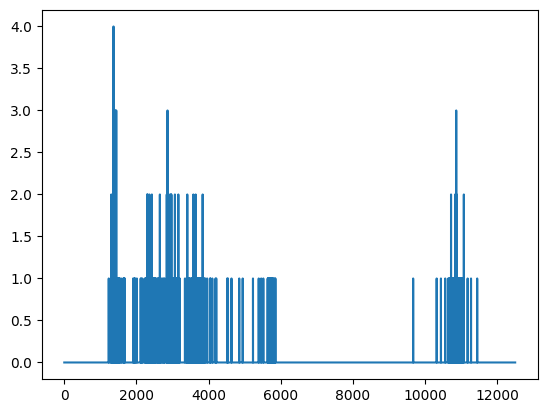

In [13]:
start_scope()
model, trace_L4E, trace_TC, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I = model_mechano_TH_CTX(SA1_position_x_fav, SA1_position_y_fav, SA2_position_x_fav, SA2_position_y_fav, RA_position_x_fav, RA_position_y_fav, 
                         S4_src, S5_src, S6_src, VPM_to_L4E_src, VPM_to_L4I_src, L4E_to_L4E_src, L4E_to_L4I_src, L4I_to_L4E_src, L4I_to_L4I_src, L4E_to_L3E_src, L4E_to_L3I_src, L4I_to_L3E_src, L3E_to_L3E_src, L3E_to_L3I_src, L3I_to_L3E_src, L3I_to_L3I_src, L3E_to_L2E_src, L3E_to_L2I_src, L3I_to_L2E_src, L3I_to_L2I_src, L2E_to_L2E_src, L2E_to_L2I_src, L2I_to_L2E_src, L2I_to_L2I_src,
                         S4_targ, S5_targ, S6_targ, VPM_to_L4E_targ, VPM_to_L4I_targ, L4E_to_L4E_targ, L4E_to_L4I_targ, L4I_to_L4E_targ, L4I_to_L4I_targ, L4E_to_L3E_targ, L4E_to_L3I_targ, L4I_to_L3E_targ, L3E_to_L3E_targ, L3E_to_L3I_targ, L3I_to_L3E_targ, L3I_to_L3I_targ, L3E_to_L2E_targ, L3E_to_L2I_targ, L3I_to_L2E_targ, L3I_to_L2I_targ, L2E_to_L2E_targ, L2E_to_L2I_targ, L2I_to_L2E_targ, L2I_to_L2I_targ)
I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
run_model_TC_CTX(position_x, position_y, amplitude, amplitudeOnOff, I, model, duration)

plt.plot(compute_spontaneous_activity(spike_L3E.t*100, duration*100))
#plt.vlines(np.argwhere(compute_spontaneous_activity(spike_RA.t, duration)/112 > 0)[0][0], 0, 0.4, linestyles='dashed', color='green')

### Spikes generation

In [ ]:
SA1_position_x_fav, SA1_position_y_fav = generate_position_x_y(24, 20, -20, 20, -20)
SA2_position_x_fav, SA2_position_y_fav = generate_position_x_y(10, 20, -20, 20, -20)
RA_position_x_fav, RA_position_y_fav = generate_position_x_y(36, 20, -20, 20, -20)
#np.savetxt('./fav_pos/SA1_x.csv', SA1_position_x_fav, delimiter=',')
#np.savetxt('./fav_pos/SA1_y.csv', SA1_position_y_fav, delimiter=',')
#np.savetxt('./fav_pos/SA2_x.csv', SA2_position_x_fav, delimiter=',')
#np.savetxt('./fav_pos/SA2_y.csv', SA2_position_y_fav, delimiter=',')
#np.savetxt('./fav_pos/RA_x.csv', RA_position_x_fav, delimiter=',')
#np.savetxt('./fav_pos/RA_y.csv', RA_position_y_fav, delimiter=',')

In [16]:
SA1_position_x_fav = np.genfromtxt('./fav_pos/SA1_x.csv')
SA1_position_y_fav = np.genfromtxt('./fav_pos/SA1_y.csv')
SA2_position_x_fav = np.genfromtxt('./fav_pos/SA2_x.csv')
SA2_position_y_fav = np.genfromtxt('./fav_pos/SA2_y.csv')
RA_position_x_fav = np.genfromtxt('./fav_pos/RA_x.csv')
RA_position_y_fav = np.genfromtxt('./fav_pos/RA_y.csv')

In [ ]:
duration = 125
dt = 1 * ms
for t in range(get_nb_trial()):
    data, stimulus = read_data_preprocessed(t)
    position_x, position_y = create_stim_static_position(duration, 0, 0, dt)
    amplitude = create_stim_amp_from_data(data, dt)
    amplitudeOnOff = create_amplitude_on_off(data, 3, dt)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)

    model, trace_L4E, trace_TC, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC, spike_L4E, spike_L4I, spike_L3E, spike_L3I, spike_L2E, spike_L2I = model_mechano_TH_CTX(SA1_position_x_fav, SA1_position_y_fav, SA2_position_x_fav, SA2_position_y_fav, RA_position_x_fav, RA_position_y_fav, 
                         S4_src, S5_src, S6_src, VPM_to_L4E_src, VPM_to_L4I_src, L4E_to_L4E_src, L4E_to_L4I_src, L4I_to_L4E_src, L4I_to_L4I_src, L4E_to_L3E_src, L4E_to_L3I_src, L4I_to_L3E_src, L3E_to_L3E_src, L3E_to_L3I_src, L3I_to_L3E_src, L3I_to_L3I_src, L3E_to_L2E_src, L3E_to_L2I_src, L3I_to_L2E_src, L3I_to_L2I_src, L2E_to_L2E_src, L2E_to_L2I_src, L2I_to_L2E_src, L2I_to_L2I_src,
                         S4_targ, S5_targ, S6_targ, VPM_to_L4E_targ, VPM_to_L4I_targ, L4E_to_L4E_targ, L4E_to_L4I_targ, L4I_to_L4E_targ, L4I_to_L4I_targ, L4E_to_L3E_targ, L4E_to_L3I_targ, L4I_to_L3E_targ, L3E_to_L3E_targ, L3E_to_L3I_targ, L3I_to_L3E_targ, L3I_to_L3I_targ, L3E_to_L2E_targ, L3E_to_L2I_targ, L3I_to_L2E_targ, L3I_to_L2I_targ, L2E_to_L2E_targ, L2E_to_L2I_targ, L2I_to_L2E_targ, L2I_to_L2I_targ)
    run_model_TC_CTX(position_x, position_y, amplitude, amplitudeOnOff, I, model, duration)

    np.savetxt('./neural_activity/SA1/spike_time/' + stimulus + '.csv', spike_SA1.t, delimiter=',')
    np.savetxt('./neural_activity/SA2/spike_time/' + stimulus + '.csv', spike_SA2.t, delimiter=',')
    np.savetxt('./neural_activity/RA/spike_time/' + stimulus + '.csv', spike_RA.t, delimiter=',')
    np.savetxt('./neural_activity/TG/spike_time/' + stimulus + '.csv', spike_TG.t, delimiter=',')
    np.savetxt('./neural_activity/BS/spike_time/' + stimulus + '.csv', spike_BS.t, delimiter=',')
    np.savetxt('./neural_activity/TC/spike_time/' + stimulus + '.csv', spike_TC.t, delimiter=',')
    np.savetxt('./neural_activity/L4E/spike_time/' + stimulus + '.csv', spike_L4E.t, delimiter=',')
    np.savetxt('./neural_activity/L4I/spike_time/' + stimulus + '.csv', spike_L4I.t, delimiter=',')
    np.savetxt('./neural_activity/L3E/spike_time/' + stimulus + '.csv', spike_L3E.t, delimiter=',')
    np.savetxt('./neural_activity/L3I/spike_time/' + stimulus + '.csv', spike_L3I.t, delimiter=',')
    np.savetxt('./neural_activity/L2E/spike_time/' + stimulus + '.csv', spike_L2E.t, delimiter=',')
    np.savetxt('./neural_activity/L2I/spike_time/' + stimulus + '.csv', spike_L2I.t, delimiter=',')

    np.savetxt('./neural_activity/SA1/spike_id/' + stimulus + '.csv', spike_SA1.i, delimiter=',')
    np.savetxt('./neural_activity/SA2/spike_id/' + stimulus + '.csv', spike_SA2.i, delimiter=',')
    np.savetxt('./neural_activity/RA/spike_id/' + stimulus + '.csv', spike_RA.i, delimiter=',')
    np.savetxt('./neural_activity/TG/spike_id/' + stimulus + '.csv', spike_TG.i, delimiter=',')
    np.savetxt('./neural_activity/BS/spike_id/' + stimulus + '.csv', spike_BS.i, delimiter=',')
    np.savetxt('./neural_activity/TC/spike_id/' + stimulus + '.csv', spike_TC.i, delimiter=',')
    np.savetxt('./neural_activity/L4E/spike_id/' + stimulus + '.csv', spike_L4E.i, delimiter=',')
    np.savetxt('./neural_activity/L4I/spike_id/' + stimulus + '.csv', spike_L4I.i, delimiter=',')
    np.savetxt('./neural_activity/L3E/spike_id/' + stimulus + '.csv', spike_L3E.i, delimiter=',')
    np.savetxt('./neural_activity/L3I/spike_id/' + stimulus + '.csv', spike_L3I.i, delimiter=',')
    np.savetxt('./neural_activity/L2E/spike_id/' + stimulus + '.csv', spike_L2E.i, delimiter=',')
    np.savetxt('./neural_activity/L2I/spike_id/' + stimulus + '.csv', spike_L2I.i, delimiter=',')

WARNING    C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_33932\1800875257.py:4: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  num_files = sum(1 for p in folder.iterdir() if p.is_file())
 [py.warnings]
WARNING    (string):89: RuntimeWarning: overflow encountered in exp
 [py.warnings]
WARNING    (string):90: RuntimeWarning: overflow encountered in exp
 [py.warnings]
WARNING    (string):91: RuntimeWarning: overflow encountered in exp
 [py.warnings]
WARNING    (string):92: RuntimeWarning: overflow encountered in exp
 [py.warnings]
WARNING    (string):68: RuntimeWarning: overflow encountered in exp
 [py.warnings]
WARNING    (string):69: RuntimeWarning: overflow encountered in exp
 [py.warnings]
WARNING    (string):70: RuntimeWarning: overflow encountered in exp
 [py.warnings]
WARNING    (string):71: RuntimeWarning: overflow encountered in exp
 [py.warn